In [1]:
from IPython.display import display, HTML, Image
display(HTML("<style>.container { width:100% !important; }</style>"))

from hashlib import md5

import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib.colors import ListedColormap
from tqdm import tqdm

from scipy.stats import chi2_contingency, chi2, ttest_ind_from_stats, norm, binom, mannwhitneyu, t, chisquare
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportion_confint 

from datetime import datetime
pd.set_option('display.max_colwidth', None)

from exp_tools.stat_tools import * 

import plotly.offline as pyo
import plotly.io as pio
pio.renderers.default = 'iframe'


In [2]:
def vertical_plot_lines(x, xal, yal, **kwargs):
    plt.axvline(x.mean(), linestyle = '--', color = kwargs.get("color", "g"), alpha = 0.5)
    tx_mean = "mean: {:.1%}".format(x.mean())
    txkw = dict(size=11, color = kwargs.get("color", "g"), rotation=90)
    plt.text(x.mean()+xal, yal, tx_mean, **txkw)


def plot_distribution(df, metric, **kwargs):
    g = sns.FacetGrid(
        data=df,
        aspect=3, height = 5,
        hue = 'variant', row = kwargs.get('row',None)
    ) 
    g.map(sns.distplot, metric, hist=kwargs.get('displot_hist',False), kde_kws={'bw': kwargs.get('kde_bandwidth','silverman')})
    g.map(vertical_plot_lines, metric, xal=  kwargs.get('xal',0.10), yal=kwargs.get('yal',0.5))
    g.fig.suptitle("Distribution between variants - {}".format(metric))
    g.set_xlabels("{}".format(metric))
    g.set_ylabels("density")
    g.set(xlim = kwargs.get('xlim', (-10,10)))
    g.add_legend()
    plt.subplots_adjust(top=0.9)
    for ax in g.axes:
        ax[0].axvline(x=0, color="black", ls=':')

In [3]:
from scipy.stats import chi2_contingency, chi2, ttest_ind_from_stats, norm, binom, mannwhitneyu, t, chisquare
from statsmodels.stats.proportion import proportion_confint 

def calculate_req_traffic_for_power(alpha, beta, base_rate, expected_effect):
    za = norm.ppf(1 - alpha/2)
    zb = norm.ppf(1 - beta)
    mde = (base_rate * expected_effect) 
    sigma = np.sqrt((base_rate) * (1-base_rate))
    sample_size_variant = 2 * (sigma**2) * (za + zb)**2 / (mde**2)
    return int(sample_size_variant)

def calculate_mde_from_traffic(alpha, beta, base_rate, n_variant):
    za = norm.ppf(1 - alpha/2)
    zb = norm.ppf(1 - beta)
    sigma = np.sqrt((base_rate) * (1-base_rate))
    
    mde = np.sqrt(2 * (sigma**2) * (za + zb)**2 / n_variant)
    
#     print(
#         f'MDE (percentage effect) = {mde/base_rate:.2%}',
#         f'\nMDE (absolute effect) = {base_rate:.2%} +- {mde:.2%}',
#         f'\nEffect identifiable outside the range [{base_rate - mde:.2%},{base_rate + mde:.2%}]\n------'
#     )
    
    return mde / BASE_RATE


ALPHA = 0.05
BETA = 0.2 # (1 - power)
BASE_RATE = 0.05
N_VARIANT = 20000

EXPECTED_UPLIFT_PERC = 0.05
N_VARIANTS = 2
N_DAYS = 14

print(
      f'MDE (absolute effect) = +- {BASE_RATE*(1+EXPECTED_UPLIFT_PERC) - BASE_RATE:.2%}',
      f'\nEffect identifiable outside the range [{BASE_RATE*(1-EXPECTED_UPLIFT_PERC):.2%},{BASE_RATE*(1+EXPECTED_UPLIFT_PERC):.2%}]\n------'
)

req_total_exp_traffic = calculate_req_traffic_for_power(
    alpha=ALPHA, 
    beta=BETA, 
    base_rate=BASE_RATE, 
    expected_effect=EXPECTED_UPLIFT_PERC)

req_daily_traffic = req_total_exp_traffic / (N_DAYS)
print(f'{req_total_exp_traffic:.0f} \t=== Total required unique visitors per variant')
print(f'{req_daily_traffic:.0f} \t=== Required daily unique visitors per variant, for experiment run of {N_DAYS} days')
print(f'\n{req_total_exp_traffic*N_VARIANTS:.0f} \t=== Total required visitors\n--------')

calculate_mde_from_traffic(
    alpha=ALPHA, 
    beta=BETA, 
    base_rate=BASE_RATE, 
    n_variant=req_total_exp_traffic
) 

MDE (absolute effect) = +- 0.25% 
Effect identifiable outside the range [4.75%,5.25%]
------
119302 	=== Total required unique visitors per variant
8522 	=== Required daily unique visitors per variant, for experiment run of 14 days

238604 	=== Total required visitors
--------


np.float64(0.0500002036764108)

# Simulating non-inferiority

In [4]:
ALPHA = 0.05 # two sided
BETA = 0.2 # (1 - power)
BASE_RATE = 0.05
TRUE_EFFECT = 0.07
SAMPLE_SIZE = int(250000) # 238604



responses = {}
for i in tqdm(range(100)):
    df_exp = pd.DataFrame({'variant': np.round(np.random.uniform(0,1,SAMPLE_SIZE))})

    df_exp['metric'] = np.random.binomial(
        n=1, 
        p=BASE_RATE, 
        size=SAMPLE_SIZE
    )

    df_exp.loc[df_exp.variant == 1, 'metric'] = np.random.binomial(
        n=1, 
        p=BASE_RATE * (1 + TRUE_EFFECT), 
        size=df_exp.loc[df_exp.variant == 1, 'metric'].shape[0]
    )


    # Test statistical power
    req_traffic = calculate_req_traffic_for_power(
        alpha=ALPHA, 
        beta=BETA, 
        base_rate=BASE_RATE, 
        expected_effect=TRUE_EFFECT)

#     print(f'\nRequired unique visitors per variant for experiment with {1-BETA:.0%} power and {ALPHA:.0%} false positive rate ===> {req_traffic:.0f}')
#     print(f'Actual traffic per variant ===> {SAMPLE_SIZE/2:.0f}')
#     print(f'Experiment is Powered: *** {SAMPLE_SIZE/2 >= req_traffic} ***\n===')

    actual_mde = calculate_mde_from_traffic(
        alpha=ALPHA, 
        beta=BETA, 
        base_rate=BASE_RATE, 
        n_variant=SAMPLE_SIZE/2
    )
#     print(f'True effect: {TRUE_EFFECT:.2%}, MDE: {actual_mde:.2%}\n======\n')

    # Get experiment results per metric (Elaborate)

    response = get_results(
        df_exp, 
        metric_field='metric', 
        confidence=0.9, 
        threshold=None, 
        calculate_ratio=True,
        plot=False
        
    )
    
    responses[i] = response

  0%|          | 0/100 [00:00<?, ?it/s]

metric


pval = 0.00000, significant at 10%: True


    variant  visitors  reached_goal  average_value      stdv  binary
0      0.0    125334          6179       0.049300  0.216495    True
1      1.0    124666          6690       0.053663  0.225353    True 

Estimate: 8.850%,     CI = [0.05818, 0.11973]


metric


pval = 0.00004, significant at 10%: True


    variant  visitors  reached_goal  average_value      stdv  binary
0      0.0    125022          6232       0.049847  0.217630    True
1      1.0    124978          6686       0.053497  0.225024    True 

Estimate: 7.323%,     CI = [0.04339, 0.10395]


  2%|▏         | 2/100 [00:00<00:05, 18.31it/s]

metric


pval = 0.00002, significant at 10%: True


    variant  visitors  reached_goal  average_value      stdv  binary
0      0.0    125209          6231       0.049765  0.217460    True
1      1.0    124791          6681       0.053538  0.225104    True 

Estimate: 7.581%,     CI = [0.04590, 0.10661]


...

metric


pval = 0.00000, significant at 10%: True


    variant  visitors  reached_goal  average_value      stdv  binary
0      0.0    124960          6153       0.049240  0.216369    True
1      1.0    125040          6828       0.054607  0.227212    True 

Estimate: 10.899%,     CI = [0.07822, 0.14069]


 98%|█████████▊| 98/100 [00:03<00:00, 24.73it/s]

metric


pval = 0.00001, significant at 10%: True


    variant  visitors  reached_goal  average_value      stdv  binary
0      0.0    124712          6171       0.049482  0.216873    True
1      1.0    125288          6692       0.053413  0.224856    True 

Estimate: 7.944%,     CI = [0.04936, 0.11042]


metric


pval = 0.00046, significant at 10%: True


    variant  visitors  reached_goal  average_value      stdv  binary
0      0.0    125235          6263       0.050010  0.217966    True
1      1.0    124765          6626       0.053108  0.224249    True 

Estimate: 6.194%,     CI = [0.03239, 0.09237]


100%|██████████| 100/100 [00:03<00:00, 26.69it/s]


In [5]:
def get_results(data, metric_field, confidence=0.9, threshold=None, calculate_ratio=True, **kwargs):
    df_stats = get_df_stats(data, metric_field)
    stats = get_stats(df_stats, non_inferioirity_threshold=threshold)
    
    if (threshold is not None):
        confidence = 1 - (1 - confidence)*2
        
    if kwargs.get('mannwhitney'):
        get_mann_whitney_test(data, metric_field, confidence)
    
    if kwargs.get('plot') is not None:
        plot_arg = kwargs.get('plot')
    else:
        plot_arg = False
        

    estimate, ci_l, ci_h = get_ci(
        df_stats,
        metric_field,
        confidence=confidence, 
        plot = plot_arg, 
        non_inferioirty_threshold=threshold,
        ratio = calculate_ratio
    )
    
    response = {'estimate':estimate,
                'ci_l':ci_l, 
                'ci_h':ci_h,
                'p-value': stats['p-value']
               }
    
    return response


def get_ci(df_stats, metric_field, confidence=0.9, plot = True, non_inferioirty_threshold=None, ratio=True):
    
    if df_stats['binary'].all() == True:
        estimate, ci_l, ci_h = improv_interval_binomial(
            confidence = confidence, 
            successes_base=df_stats.at[0, 'reached_goal'], 
            successes_var=df_stats.at[1, 'reached_goal'], 
            obs_base=df_stats.at[0, 'visitors'], 
            obs_var=df_stats.at[1, 'visitors'])
        # print("Estimate: {:.3%},     CI = [{:.5f}, {:.5f}]".format(estimate, ci_l, ci_h))
    else:     
        if ratio:
            estimate, ci_l, ci_h = confidence_interval_ratio(
                confidence = confidence, 
                avg_base = df_stats.at[0, 'reached_goal']/df_stats.at[0, 'visitors'], 
                avg_var = df_stats.at[1, 'reached_goal']/df_stats.at[1, 'visitors'], 
                stdev_base = df_stats.at[0, 'stdv'],  
                stdev_var = df_stats.at[1, 'stdv'], 
                obs_base=df_stats.at[0, 'visitors'], 
                obs_var=df_stats.at[1, 'visitors'])
            # print("Estimate: {:.3%},     CI = [{:.5f}, {:.5f}]".format(estimate, ci_l, ci_h))
        else:
            estimate, ci_l, ci_h = confidence_interval_mean_differences(
                confidence = confidence, 
                avg_base = df_stats.at[0, 'reached_goal']/df_stats.at[0, 'visitors'], 
                avg_var = df_stats.at[1, 'reached_goal']/df_stats.at[1, 'visitors'], 
                stdev_base = df_stats.at[0, 'stdv'],  
                stdev_var = df_stats.at[1, 'stdv'], 
                obs_base=df_stats.at[0, 'visitors'], 
                obs_var=df_stats.at[1, 'visitors'])
            # print("Estimate: {:.3f},     CI = [{:.5f}, {:.5f}]".format(estimate, ci_l, ci_h))
    
    if ci_h < ci_l:
        ci_l, ci_h = min(ci_l,ci_h), max(ci_l,ci_h)
    if plot:
        plot_ci(estimate, ci_l, ci_h, metric_field, non_inferioirty_threshold=non_inferioirty_threshold, ratio=ratio)
            
    return estimate, ci_l, ci_h

In [6]:
ALPHA = 0.1 # two sided
BETA = 0.2 # (1 - power)
BASE_RATE = 0.05
TRUE_EFFECT = 0.05
SAMPLE_SIZE = int(250000) # 238604


sample_sizes = []
for true_effect in [0.03, 0.04, 0.05, 0.06, 0.07]:
    powered_sample = calculate_req_traffic_for_power(
                    alpha=ALPHA, 
                    beta=BETA, 
                    base_rate=BASE_RATE, 
                    expected_effect=true_effect)
    sample_sizes.append(powered_sample * 2)

responses = {}
for sample_size in sample_sizes[::1]:
    for true_effect in [0.03, 0.04, 0.05, 0.06, 0.07]:
        for i in tqdm(range(100)):
            df_exp = pd.DataFrame({'variant': np.round(np.random.uniform(0,1,sample_size))})

            df_exp['metric'] = np.random.binomial(
                n=1, 
                p=BASE_RATE, 
                size=sample_size
            )

            df_exp.loc[df_exp.variant == 1, 'metric'] = np.random.binomial(
                n=1, 
                p=BASE_RATE * (1 + true_effect), 
                size=df_exp.loc[df_exp.variant == 1, 'metric'].shape[0]
            )


            # Test statistical power
            req_traffic = calculate_req_traffic_for_power(
                alpha=ALPHA, 
                beta=BETA, 
                base_rate=BASE_RATE, 
                expected_effect=true_effect)

            response = get_results(
                df_exp, 
                metric_field='metric', 
                confidence=0.9, 
                threshold=None, 
                calculate_ratio=True,
                plot=False

            )
            response['true_effect'] = true_effect
            response['sample_size'] = sample_size
            response['index_row'] = int(i // 10)
            response['index_col'] = int(i % 10)

            responses[f'{true_effect},{sample_size*100},{i}'] = response
            
            
stats = pd.DataFrame(responses).T 
stats['sample_size']
stats['sample_size'] = stats['sample_size'].apply(int)
stats['sig_at'] = stats['p-value'] <= 0.1
stats['sig_at'] = stats['sig_at'] * 1

stats['count_sig'] = stats.groupby(['true_effect','sample_size','sig_at'])['sig_at'].transform('count')

  0%|          | 0/100 [00:00<?, ?it/s]


pval = 0.00315, significant at 10%: True


pval = 0.01690, significant at 10%: True



  3%|▎         | 3/100 [00:00<00:03, 28.13it/s]


pval = 0.09593, significant at 10%: True


pval = 0.05673, significant at 10%: True



  6%|▌         | 6/100 [00:00<00:03, 28.44it/s]

...


pval = 0.00007, significant at 10%: True


pval = 0.01926, significant at 10%: True


pval = 0.21122, significant at 10%: False


pval = 0.00042, significant at 10%: True


pval = 0.10693, significant at 10%: False


pval = 0.02822, significant at 10%: True


pval = 0.00081, significant at 10%: True


pval = 0.00002, significant at 10%: True


pval = 0.00181, significant at 10%: True


pval = 0.01293, significant at 10%: True


pval = 0.23174, significant at 10%: False


pval = 0.05706, significant at 10%: True


pval = 0.14638, significant at 10%: False



 93%|█████████▎| 93/100 [00:00<00:00, 126.45it/s]


pval = 0.11968, significant at 10%: False


pval = 0.00051, significant at 10%: True


pval = 0.04154, significant at 10%: True


pval = 0.00037, significant at 10%: True


pval = 0.02204, significant at 10%: True


pval = 0.69232, significant at 10%: False


pval = 0.12004, significant at 10%: False


pval = 0.00062, significant at 10%: True



100%|██████████| 100/100 [00:00<00:00, 126.78it/s]


pval = 0.42894, significant at 10%: False



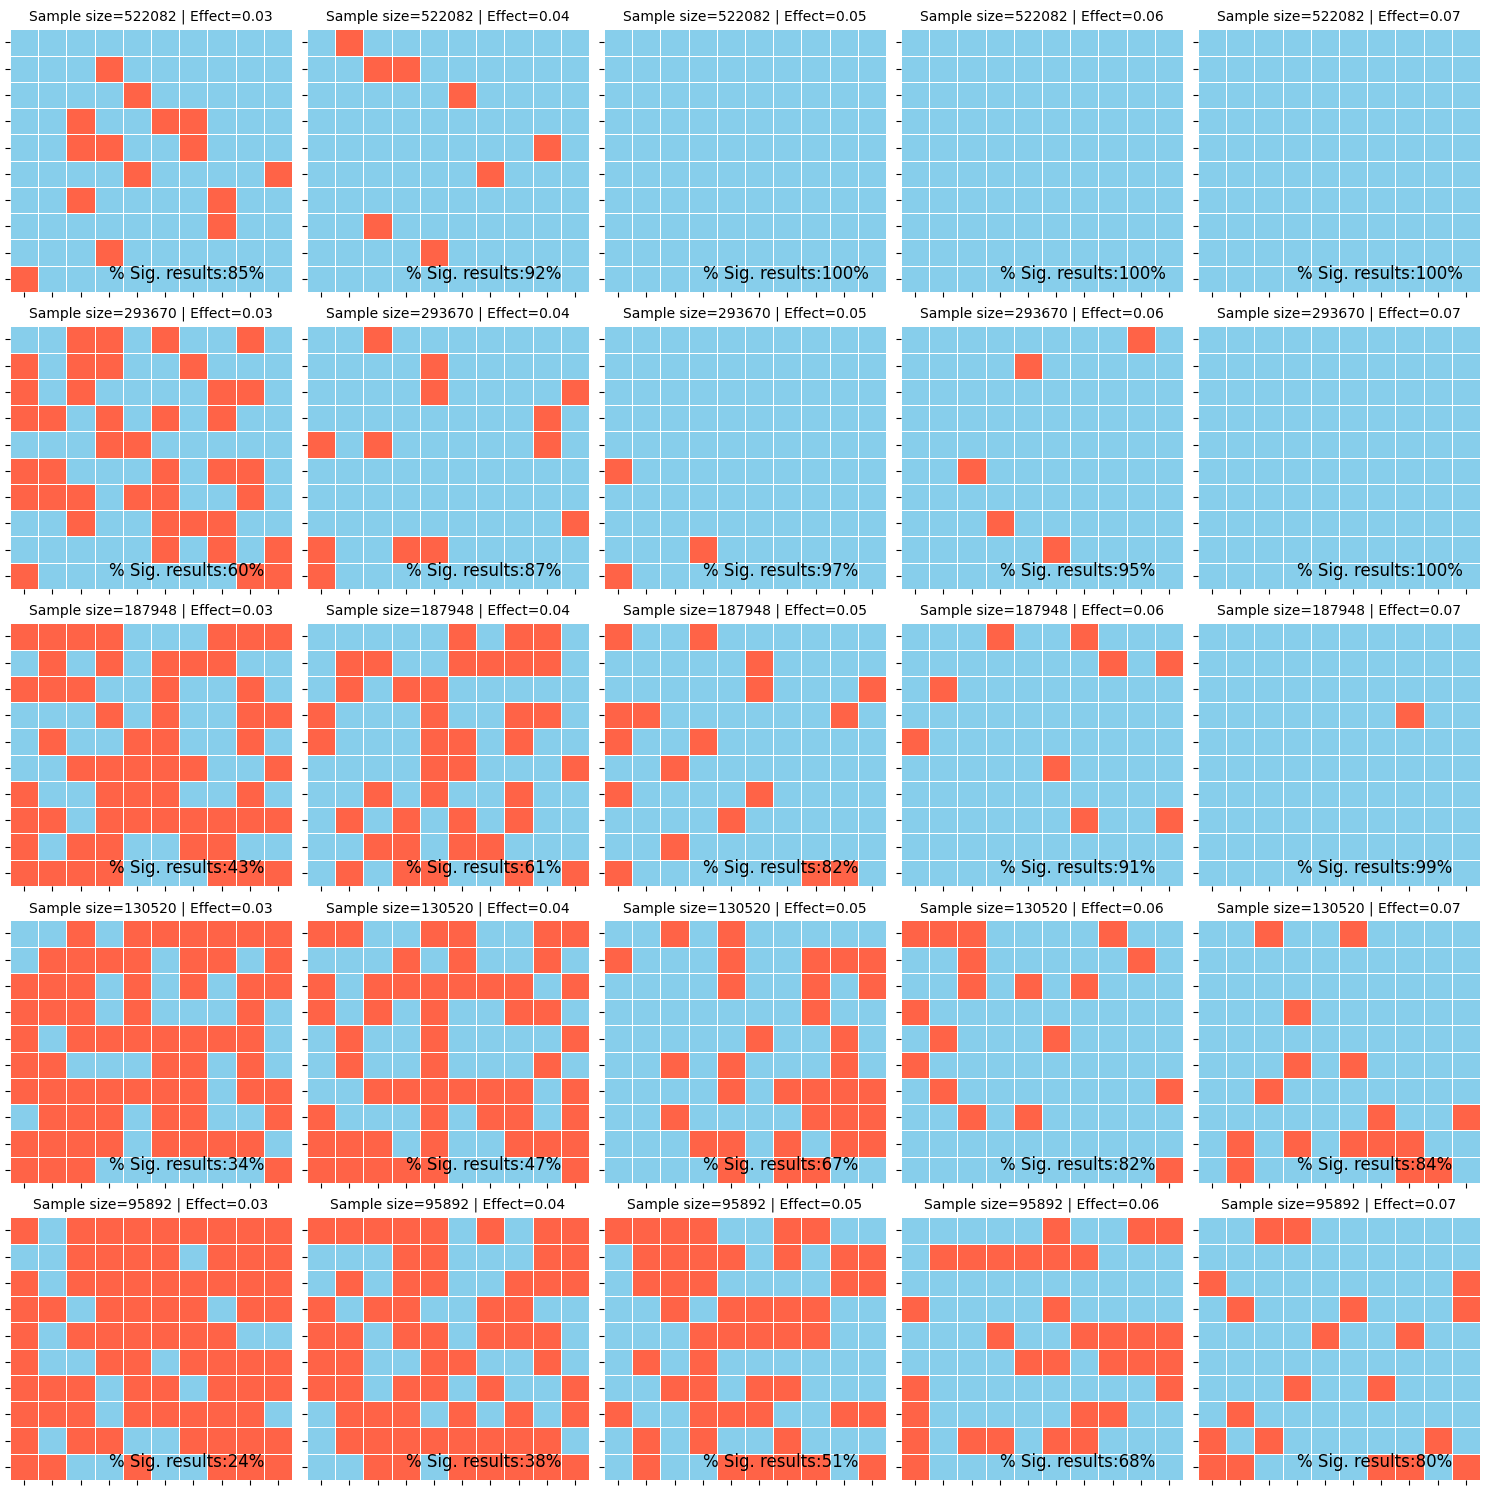

In [7]:
def draw_heatmap(data, row_var, col_var, value_var, **kwargs):
    data_pivot = data.pivot(
        index=row_var, columns=col_var, values=value_var
    )
    sns.heatmap(
        data_pivot,
        **kwargs
    )
    

def annotate_mean(data, metric, **kwargs):
    tx_mean = data[metric].mean()
    tx_mean = f"% Sig. results:{data[metric].mean():.0%}"
    txkw = dict(size=12)
    plt.text(3.5, 9.5, tx_mean, **txkw)
    

g = sns.FacetGrid(
    stats,
    col='true_effect',
    row='sample_size',
    height=3, aspect=1,
    row_order=sample_sizes
    
)
g.map_dataframe(draw_heatmap, row_var='index_row', col_var='index_col', value_var='sig_at',
                vmin=0,vmax=1,
                cmap=ListedColormap(['tomato', 'skyblue']),
                annot=False, linewidth=0.5, alpha=1, cbar=False
               )
g.map_dataframe(annotate_mean, metric='sig_at')


for ax in g.axes.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    
g.set_titles(row_template="Sample size={row_name}", col_template="Effect={col_name}")
g.figure.tight_layout()

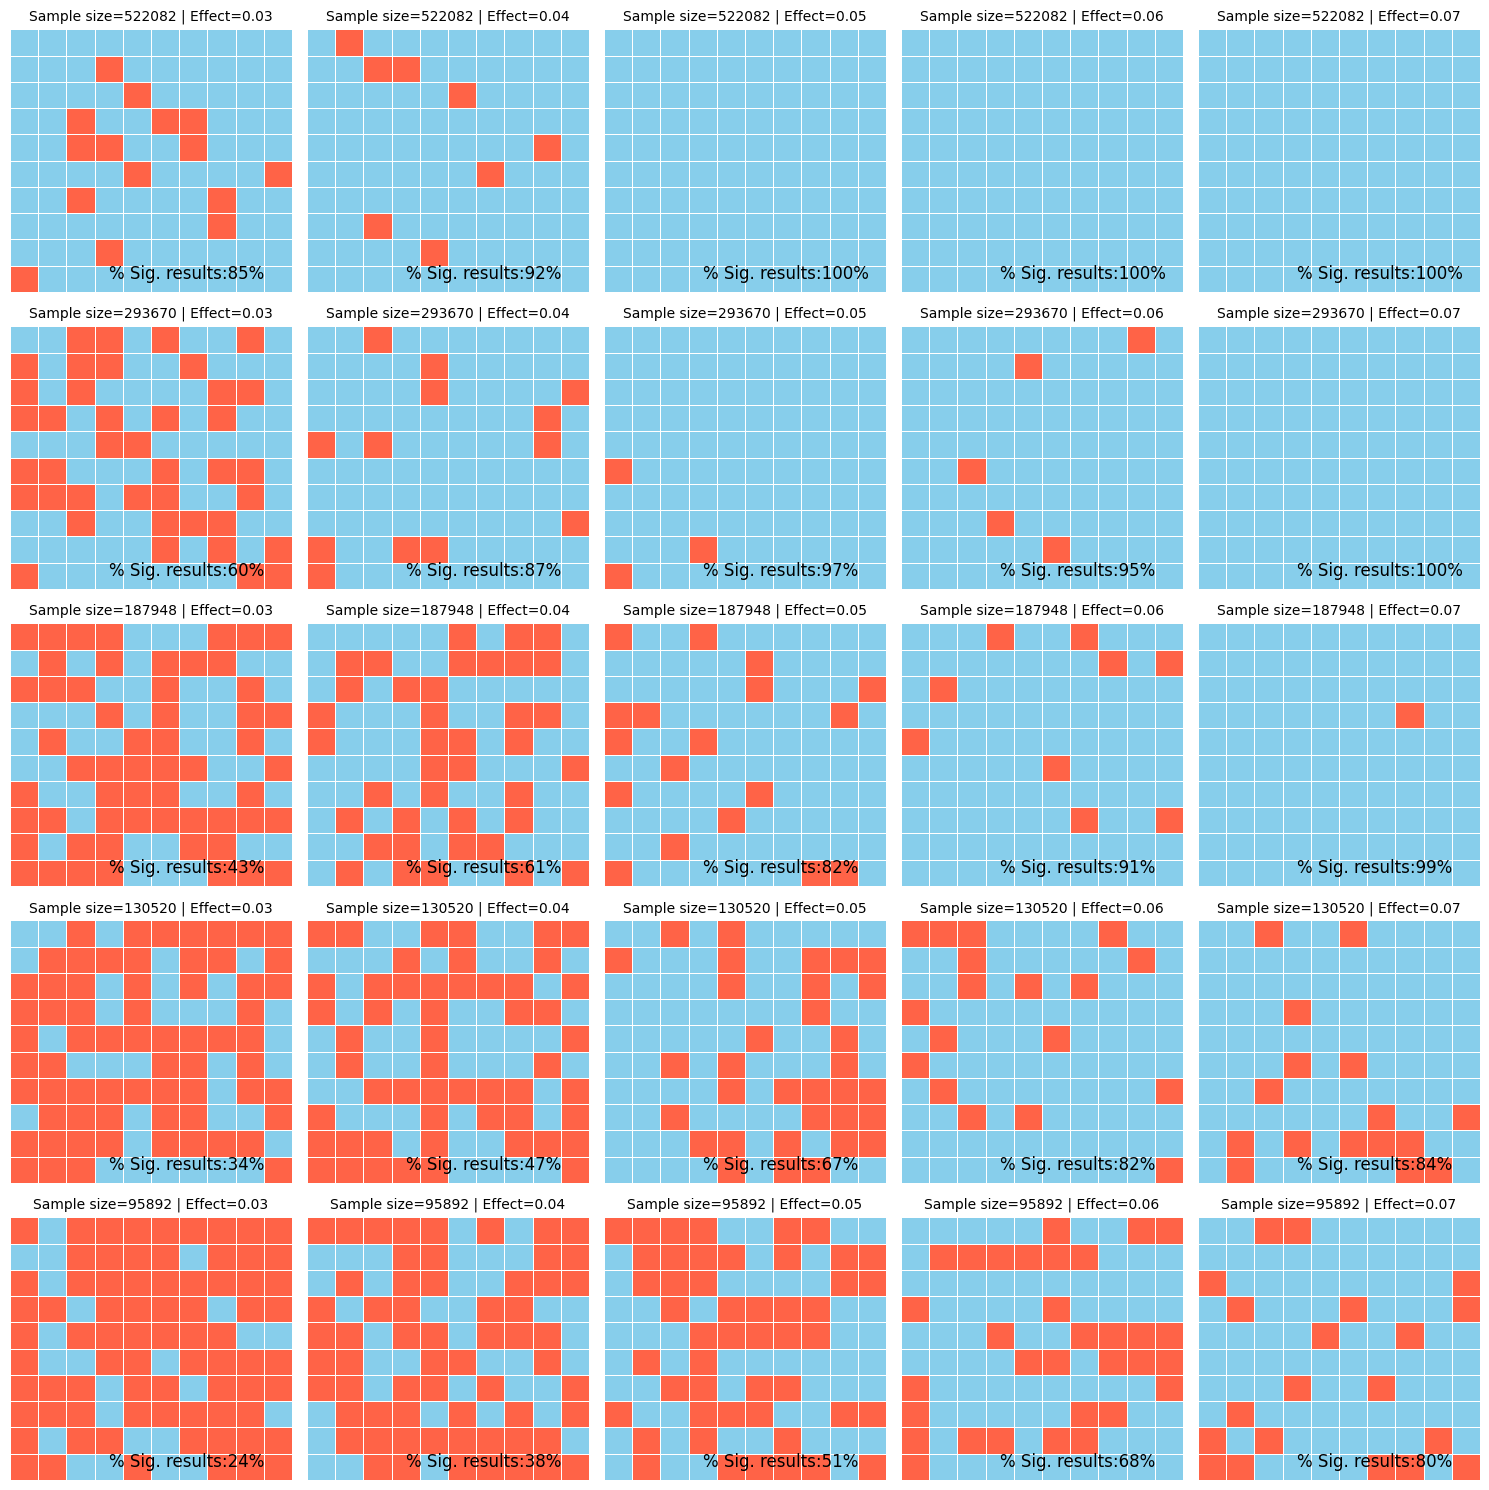

In [8]:
g = sns.FacetGrid(
    stats,
    col='true_effect',
    row='sample_size',
    height=3, aspect=1,
    row_order=sample_sizes
    
)
g.map_dataframe(draw_heatmap, row_var='index_row', col_var='index_col', value_var='sig_at',
                vmin=0,vmax=1,
                cmap=ListedColormap(['tomato', 'skyblue']),
                annot=False, linewidth=0.5, alpha=1, cbar=False
               )
g.map_dataframe(annotate_mean, metric='sig_at')


for ax in g.axes.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_xticks([])
    ax.set_yticks([])
    
g.set_titles(row_template="Sample size={row_name}", col_template="Effect={col_name}")
g.figure.tight_layout()

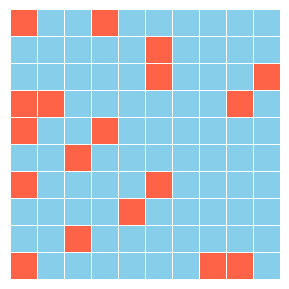

In [9]:
g = sns.FacetGrid(
        (stats.loc[
        (stats['count_sig']>=10) &
        (stats['sample_size']==187948) &
        (stats['true_effect']==0.05)
    ]),
#     col='true_effect',
#     row='sample_size',
    height=3, aspect=1,
    row_order=sample_sizes
    
)
g.map_dataframe(draw_heatmap, row_var='index_row', col_var='index_col', value_var='sig_at',
                vmin=0,vmax=1,
                cmap=ListedColormap(['tomato', 'skyblue']),
                annot=False, linewidth=0.5, alpha=1, cbar=False
               )
# g.map_dataframe(annotate_mean, metric='sig_at')


for ax in g.axes.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_xticks([])
    ax.set_yticks([])
    
# g.set_titles(row_template="Sample size={row_name}", col_template="Effect={col_name}")
g.figure.tight_layout()

In [10]:
stats.head()

,estimate,ci_l,ci_h,p-value,true_effect,sample_size,index_row,index_col,sig_at,count_sig
"0.03,52208200,0",0.035936,0.015763,0.056518,0.003148,0.03,522082,0.0,0.0,1,85
"0.03,52208200,1",0.029168,0.008995,0.049751,0.016902,0.03,522082,0.0,1.0,1,85
"0.03,52208200,2",0.020196,0.000241,0.040553,0.095927,0.03,522082,0.0,2.0,1,85
"0.03,52208200,3",0.023067,0.003123,0.043413,0.056734,0.03,522082,0.0,3.0,1,85
"0.03,52208200,4",0.035777,0.015489,0.056478,0.003468,0.03,522082,0.0,4.0,1,85


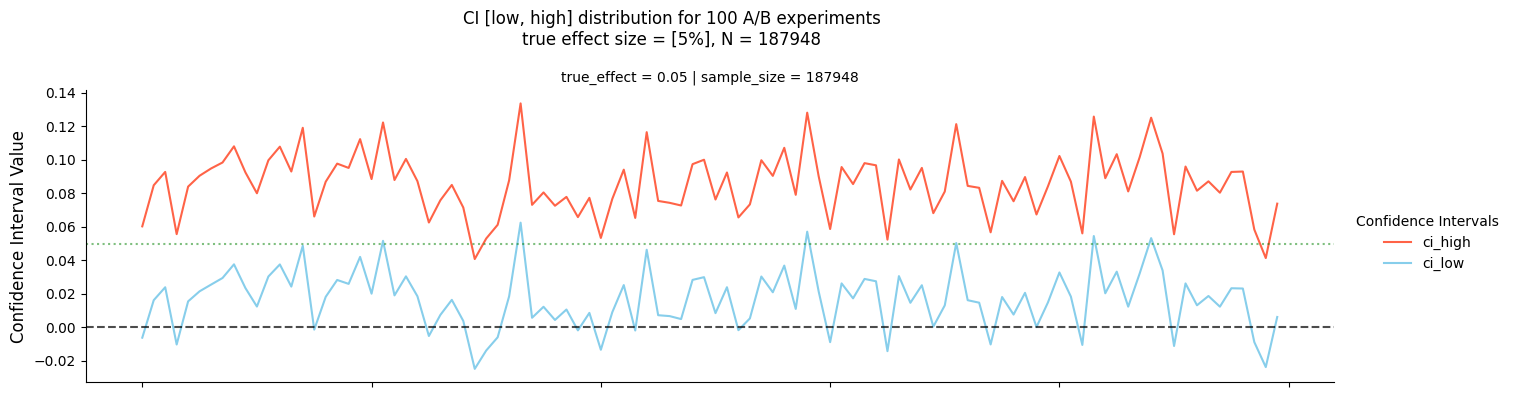

In [11]:
stats['index'] = [i for i in range(len(stats))]

stats_plot = stats.loc[
        (stats['true_effect']==0.05) & (stats['sample_size']==187948)  
             ]

g = sns.FacetGrid(
    stats_plot,
    col = 'sample_size', row = 'true_effect',
    height=4, aspect=3, sharex=True, 
)

g.map_dataframe(
    sns.lineplot,
    x='index',
    y='ci_h',
    color='tomato',
    label='ci_high'
)

g.map_dataframe(
    sns.lineplot,
    x='index',
    y='ci_l',
    color='skyblue',
    label='ci_low'
)

g.refline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
g.refline(y=0.05, color='green', linestyle=':', linewidth=1.5, alpha=0.5)


for ax in g.axes.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('CI')
    ax.set_xticklabels([])
    
# Add axis labels
g.set_axis_labels('', 'Confidence Interval Value', fontsize=12)

# Add legend
g.add_legend(title='Confidence Intervals', fontsize=10)
sns.move_legend(g, "upper right", bbox_to_anchor=(1.12, 0.5), frameon=False)
    
g.fig.suptitle(f"CI [low, high] distribution for 100 A/B experiments\ntrue effect size = [{stats_plot.true_effect.unique()[0]:.0%}], N = {stats_plot.sample_size.unique()[0]}")
g.fig.tight_layout()


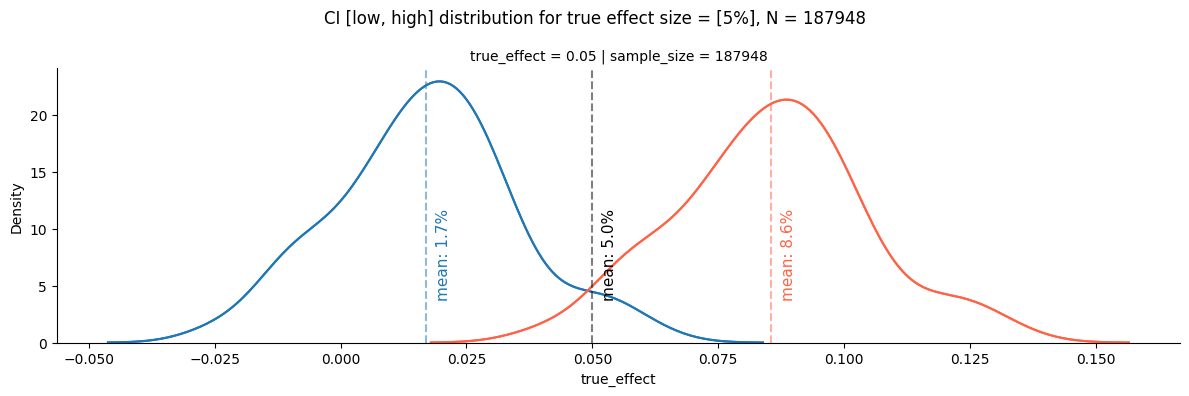

In [12]:
g = sns.FacetGrid(
    stats.loc[
        (stats['true_effect']==0.05) & (stats['sample_size']==187948)  
             ],
    col = 'sample_size', row = 'true_effect',
    height=4, aspect=3, sharex=True, 
)

g.map_dataframe(sns.kdeplot, x='ci_l')
g.map(sns.kdeplot, 'ci_l')
g.map(vertical_plot_lines, 'ci_l', xal=0.002, yal=4)

g.map_dataframe(sns.kdeplot, x='ci_h', color='tomato')
g.map(sns.kdeplot, 'ci_h', color='tomato')
g.map(vertical_plot_lines, 'ci_h', color='tomato', xal=0.002, yal=4)
g.map(vertical_plot_lines, 'true_effect', linestyle = '--', color='black', xal=0.002, yal=4)

g.fig.suptitle("CI [low, high] distribution for true effect size = [5%], N = 187948")
g.fig.tight_layout()

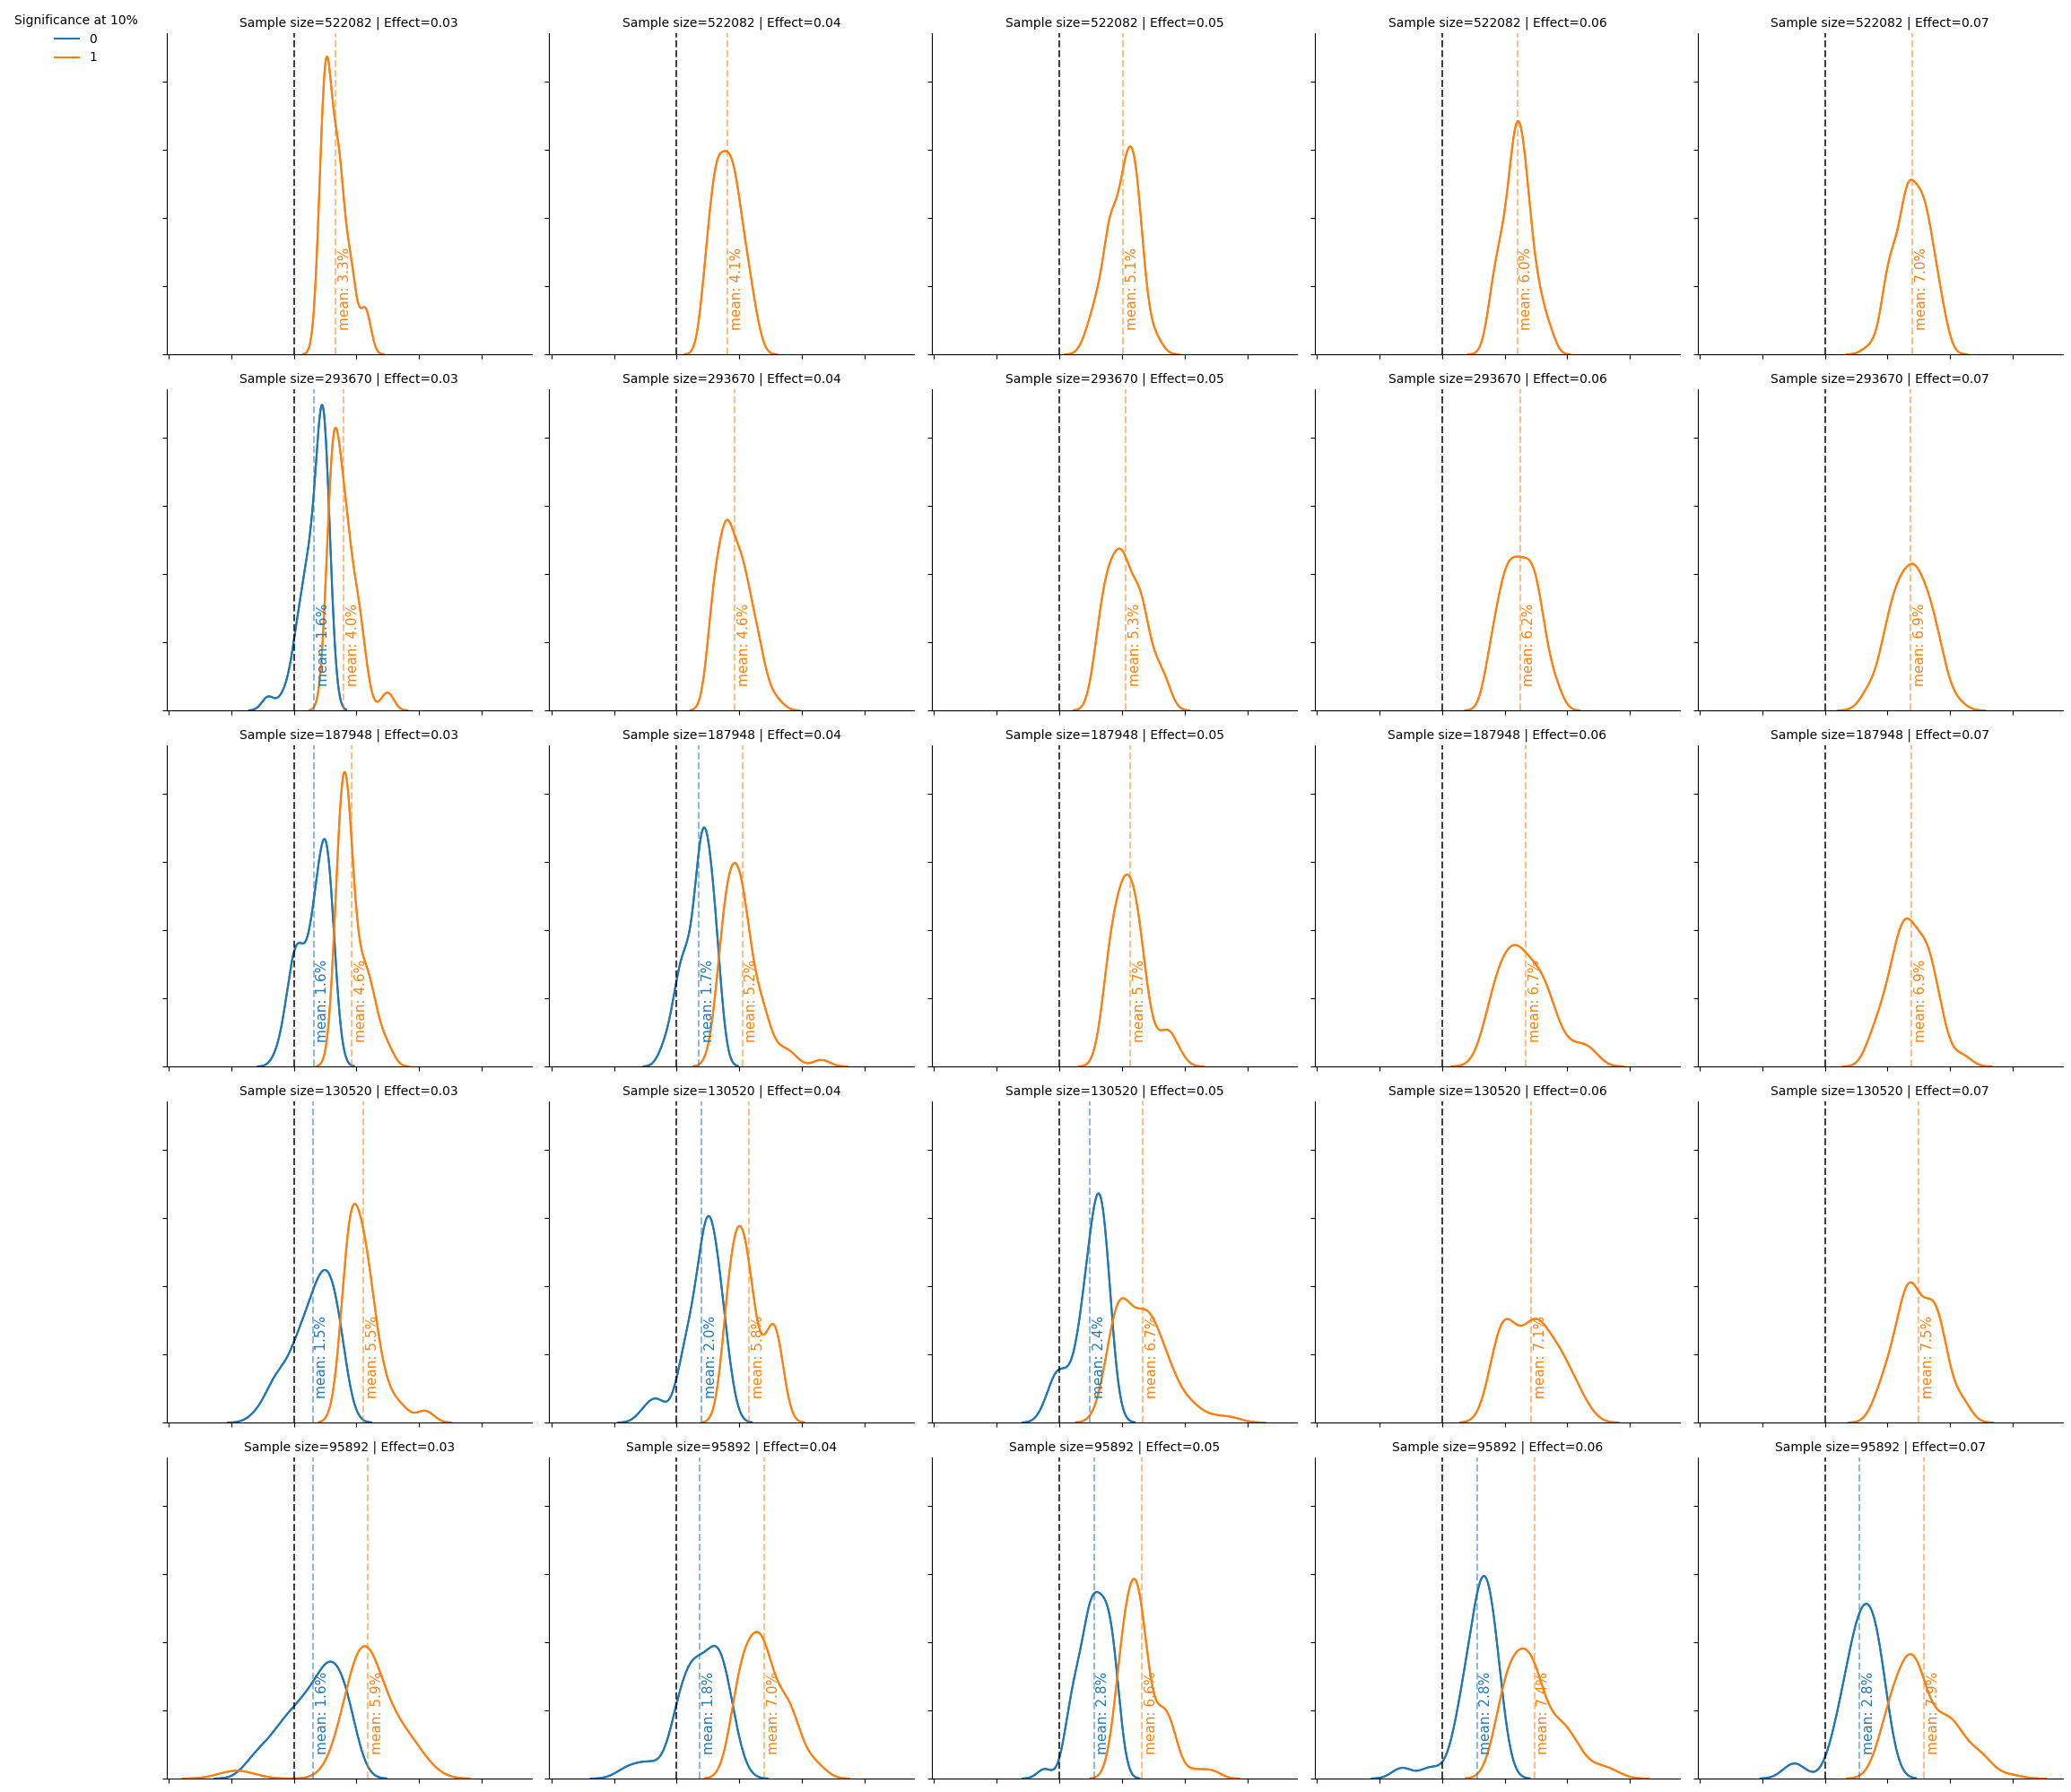

In [13]:
g = sns.FacetGrid(
    stats.loc[stats['count_sig']>=20],
    col='true_effect',
    row='sample_size',
    hue='sig_at',
    height=4, aspect=1, sharex=True,
    row_order=sample_sizes
    
)
g.map_dataframe(sns.kdeplot, x='estimate')
g.map(sns.kdeplot, 'estimate')
g.map(vertical_plot_lines, 'estimate', xal=0.002, yal=4)
# g.map(vertical_plot_lines, 'true_effect', xal=0.005, yal=50, color='tomato')


for ax in g.axes.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    ax.axvline(0, linestyle = '--', color = "black", alpha = 0.75)
# plt.axvline(stats['true_effect'].mean(), linestyle = ':', color = "black", alpha = 0.75)
# plt.text(stats['true_effect'].mean()+0.0015, 4, f"True effect: {stats['true_effect'].mean():.1%}", rotation=90)
    
    
g.add_legend(title="Significance at 10%")
sns.move_legend(g, "upper right", bbox_to_anchor=(0, 1), frameon=False)
g.set_titles(row_template="Sample size={row_name}", col_template="Effect={col_name}")
g.figure.tight_layout()

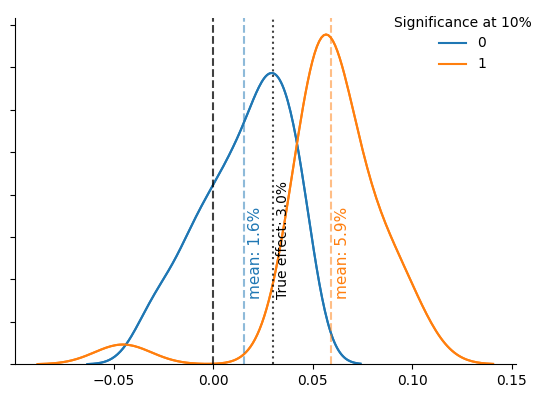

In [14]:
plot_stats = stats.loc[
        (stats['count_sig']>=10) &
        (stats['sample_size']<96892) &
        (stats['true_effect']==0.03)
    ]

g = sns.FacetGrid(
    plot_stats,
#     col='true_effect',
#     row='sample_size',
    hue='sig_at',
    height=4, aspect=1, sharex=True,
    row_order=sample_sizes
    
)
g.map_dataframe(sns.kdeplot, x='estimate')
g.map(sns.kdeplot, 'estimate')
g.map(vertical_plot_lines, 'estimate', xal=0.002, yal=4)
# g.map(vertical_plot_lines, 'true_effect', xal=0.005, yal=50, color='tomato')


for ax in g.axes.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('')
#     ax.set_xticklabels([])
    ax.set_yticklabels([])

plt.axvline(0, linestyle = '--', color = "black", alpha = 0.75)
plt.axvline(plot_stats['true_effect'].mean(), linestyle = ':', color = "black", alpha = 0.75)
plt.text(plot_stats['true_effect'].mean()+0.0015, 4, f"True effect: {plot_stats['true_effect'].mean():.1%}", rotation=90)
    
    
g.add_legend(title="Significance at 10%")
sns.move_legend(g, "upper right", bbox_to_anchor=(1, 1), frameon=False)
g.set_titles(row_template="Sample size={row_name}", col_template="Effect={col_name}")
g.figure.tight_layout()

# Non parametric test

In [15]:
def vertical_plot_lines(x, xal, yal, **kwargs):
    plt.axvline(x.mean(), linestyle = '--', color = kwargs.get("color", "g"), alpha = 0.5)
    tx_mean = "mean: {:.1%}".format(x.mean())
    txkw = dict(size=11, color = kwargs.get("color", "g"), rotation=90)
    plt.text(x.mean()+xal, yal, tx_mean, **txkw)


def plot_distribution(df, metric, **kwargs):
    g = sns.FacetGrid(
        data=df,
        aspect=3, height = 5,
        hue = 'variant', row = kwargs.get('row',None)
    ) 
    g.map(sns.distplot, metric, hist=kwargs.get('displot_hist',False), kde_kws={'bw': kwargs.get('kde_bandwidth','silverman')})
    g.map(vertical_plot_lines, metric, xal=  kwargs.get('xal',0.10), yal=kwargs.get('yal',0.5))
    g.fig.suptitle("Distribution between variants - {}".format(metric))
    g.set_xlabels("{}".format(metric))
    g.set_ylabels("density")
    g.set(xlim = kwargs.get('xlim', (-10,10)))
    g.add_legend()
    plt.subplots_adjust(top=0.9)
    for ax in g.axes:
        ax[0].axvline(x=0, color="black", ls=':')
        
        
def get_mann_whitney_test(data, metric_field, confidence=0.9):
    array_base = data.loc[data['variant'] == 0, metric_field]
    array_variant = data.loc[data['variant'] == 1, metric_field]
    u_value, p_value = mannwhitneyu(array_base, array_variant)
    
    print("Mann-Whitney p-value: {:.5f} \nstatstistical significance at {} level p_value < (1 - confidence): {}\n".format(
        p_value, confidence, p_value<(1-confidence)))
    
    return u_value, p_value
                
    

/Users/or.levkovich/git_tree/statstools/.venv/lib/python3.9/site-packages/seaborn/axisgrid.py:854: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


/Users/or.levkovich/git_tree/statstools/.venv/lib/python3.9/site-packages/seaborn/distributions.py:2496: UserWarning:



The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=silverman`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.


/Users/or.levkovich/git_tree/statstools/.venv/lib/python3.9/site-packages/seaborn/axisgrid.py:854: UserWarning:



`distplot` is a deprecated function and will be r

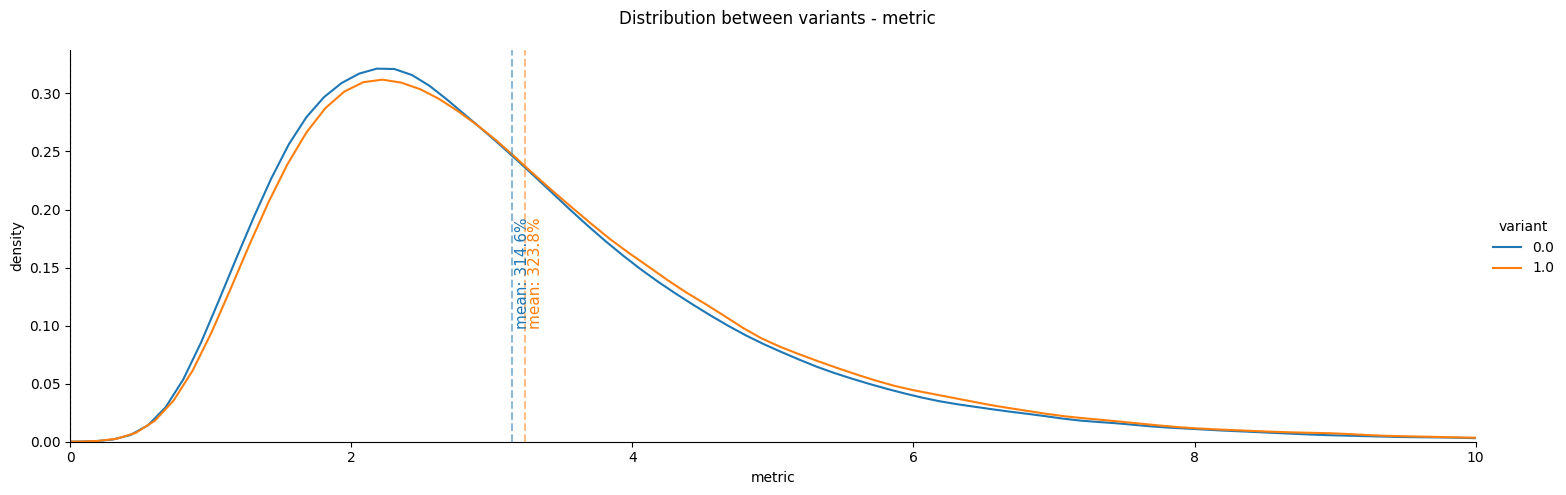

In [16]:
df_exp = pd.DataFrame({'variant': np.round(np.random.uniform(0,1,SAMPLE_SIZE))})

df_exp['metric'] = np.random.lognormal(
    1.02, 
    .5,
    SAMPLE_SIZE
)

df_exp.loc[df_exp.variant == 1, 'metric'] = np.random.lognormal(
    1.05, 
    .5,
    size=df_exp.loc[df_exp.variant == 1, 'metric'].shape[0]
)

plot_distribution(
    df_exp, 
    'metric', xlim=(0,10),
    yal=0.1, xal=0.02)

In [17]:
get_mann_whitney_test(df_exp, 'metric', confidence=0.9)

Mann-Whitney p-value: 0.00000 
statstistical significance at 0.9 level p_value < (1 - confidence): True



(np.float64(7567499443.0), np.float64(5.700580641971271e-42))

# A/A simulations

In [18]:
def run_simulation(
    num_simulations=500,
    sample_size=100000,
    true_effect = 0.0,
    base_rate = 0.05,
    ci_l_threshold = -0.01
):       
    counter_trending = 0
    counter_result_changed = 0
    responses = {}
    for i in tqdm(range(num_simulations)):

        df_exp = pd.DataFrame({'variant': np.round(np.random.uniform(0,1,sample_size))})

        df_exp['metric'] = np.random.binomial(
            n=1, 
            p=base_rate, 
            size=sample_size
        )

        df_exp.loc[df_exp.variant == 1, 'metric'] = np.random.binomial(
            n=1, 
            p=base_rate * (1 + true_effect), 
            size=df_exp.loc[df_exp.variant == 1, 'metric'].shape[0]
        )

        response = get_results(
            df_exp, 
            metric_field='metric', 
            confidence=0.9, 
            threshold=None, 
            calculate_ratio=True,
            plot=False
        )

        if (response['ci_l'] > ci_l_threshold) & (response['ci_l'] <= 0):

            counter_trending += 1

            df_exp_2 = pd.DataFrame({'variant': np.round(np.random.uniform(0,1,sample_size))})

            df_exp_2['metric'] = np.random.binomial(
                n=1, 
                p=base_rate, 
                size=sample_size
            )

            df_exp_2.loc[df_exp_2.variant == 1, 'metric'] = np.random.binomial(
                n=1, 
                p=BASE_RATE * (1 + true_effect), 
                size=df_exp_2.loc[df_exp_2.variant == 1, 'metric'].shape[0]
            )

            df_exp = pd.concat([df_exp, df_exp_2])

            response_2 = get_results(
                df_exp, 
                metric_field='metric', 
                confidence=0.9, 
                threshold=None, 
                calculate_ratio=True,
                plot=False
            )

            if response_2['ci_l'] > 0:
                counter_result_changed += 1


        response['true_effect'] = true_effect
        response['sample_size'] = sample_size
        response['index_row'] = int(i // 10)
        response['index_col'] = int(i % 10)

        responses[f'{true_effect},{sample_size*100},{i}'] = response

    stats = pd.DataFrame(responses).T 
    stats['sample_size'] = stats['sample_size'].apply(int)
    stats['sig_at'] = stats['p-value'] <= 0.1
    stats['sig_at'] = stats['sig_at'] * 1

    stats['count_sig'] = stats.groupby(['true_effect','sample_size','sig_at'])['sig_at'].transform('count')
    
    return stats, counter_trending, counter_result_changed

In [19]:
RANGE = 1000
stats, counter_trending, counter_result_changed = run_simulation(
    num_simulations=RANGE,
    sample_size=100000,
    true_effect = 0.0,
    base_rate = 0.05,
    ci_l_threshold = -0.01
)

print(f"CI trending: {counter_trending}, % of total: {counter_trending/RANGE:.2%}")
print(f"Result changed after run longer: {counter_result_changed}, % of total: {counter_result_changed/RANGE:.2%}")

  1%|          | 9/1000 [00:00<00:12, 82.18it/s]


pval = 0.57398, significant at 10%: False


pval = 0.10417, significant at 10%: False


pval = 0.38218, significant at 10%: False


pval = 0.53275, significant at 10%: False


pval = 0.16879, significant at 10%: False


pval = 0.98512, significant at 10%: False


pval = 0.29912, significant at 10%: False


pval = 0.33468, significant at 10%: False


pval = 0.73353, significant at 10%: False


pval = 0.92315, significant at 10%: False


pval = 0.47569, significant at 10%: False


pval = 0.95276, significant at 10%: False


pval = 0.78711, significant at 10%: False


pval = 0.98094, significant at 10%: False


pval = 0.46562, significant at 10%: False


pval = 0.67706, significant at 10%: False


pval = 0.82470, significant at 10%: False


pval = 0.83402, significant at 10%: False


pval = 0.65958, significant at 10%: False


pval = 0.87735, significant at 10%: False


pval = 0.85891, significant at 10%: False



  3%|▎         | 32/1000 [00:00<00:09, 104.87it/s]


pval = 0.55421, significant at 10%: False


pval = 0.08099, significant at 10%: True


pval = 0.24964, significant at 10%: False


pval = 0.41162, significant at 10%: False


pval = 0.81472, significant at 10%: False


pval = 0.17518, significant at 10%: False


pval = 0.00729, significant at 10%: True


pval = 0.26866, significant at 10%: False


pval = 0.89884, significant at 10%: False


pval = 0.31783, significant at 10%: False


pval = 0.38484, significant at 10%: False


pval = 0.05053, significant at 10%: True


pval = 0.31598, significant at 10%: False


pval = 0.04933, significant at 10%: True


pval = 0.24481, significant at 10%: False


pval = 0.89682, significant at 10%: False


pval = 0.03687, significant at 10%: True


pval = 0.35416, significant at 10%: False


pval = 0.95778, significant at 10%: False


pval = 0.67818, significant at 10%: False


pval = 0.98735, significant at 10%: False


pval = 0.60891, significant at 10%: False


pval = 0.85094, significant at 10%: 

  6%|▌         | 58/1000 [00:00<00:07, 118.34it/s]

...


pval = 0.83075, significant at 10%: False


pval = 0.61915, significant at 10%: False


pval = 0.46238, significant at 10%: False


pval = 0.53085, significant at 10%: False


pval = 0.08674, significant at 10%: True


pval = 0.91002, significant at 10%: False


pval = 0.32492, significant at 10%: False


pval = 0.68033, significant at 10%: False


pval = 0.48942, significant at 10%: False


pval = 0.30135, significant at 10%: False


pval = 0.37256, significant at 10%: False


pval = 0.40192, significant at 10%: False


pval = 0.17261, significant at 10%: False


pval = 0.84953, significant at 10%: False


pval = 0.97223, significant at 10%: False


pval = 0.19680, significant at 10%: False


pval = 0.13806, significant at 10%: False


pval = 0.55032, significant at 10%: False


pval = 0.61432, significant at 10%: False


pval = 0.16236, significant at 10%: False


pval = 0.85432, significant at 10%: False


pval = 0.52921, significant at 10%: False


pval = 0.61398, significant at 1

100%|█████████▉| 996/1000 [00:09<00:00, 119.49it/s]


pval = 0.33439, significant at 10%: False


pval = 0.49632, significant at 10%: False


pval = 0.94064, significant at 10%: False


pval = 0.62837, significant at 10%: False


pval = 0.61798, significant at 10%: False


pval = 0.78448, significant at 10%: False


pval = 0.49654, significant at 10%: False


pval = 0.82866, significant at 10%: False


pval = 0.84905, significant at 10%: False


pval = 0.00255, significant at 10%: True


pval = 0.42771, significant at 10%: False


pval = 0.58516, significant at 10%: False


pval = 0.54135, significant at 10%: False


pval = 0.33669, significant at 10%: False


pval = 0.01933, significant at 10%: True


pval = 0.19259, significant at 10%: False


pval = 0.00109, significant at 10%: True


pval = 0.63145, significant at 10%: False


pval = 0.05773, significant at 10%: True


pval = 0.15827, significant at 10%: False



100%|██████████| 1000/1000 [00:09<00:00, 110.51it/s]


pval = 0.87513, significant at 10%: False

CI trending: 56, % of total: 5.60%
Result changed after run longer: 11, % of total: 1.10%


In [20]:
stats.describe()

,estimate,ci_l,ci_h,p-value,true_effect,sample_size,index_row,index_col,sig_at,count_sig
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.0,1000.0,1000.000000,1000.000000,1000.0000,1000.0000
mean,0.000941,-0.043458,0.047401,0.498618,0.0,100000.0,49.500000,4.500000,0.1020,816.8080
std,0.027919,0.026710,0.029218,0.287878,0.0,0.0,28.880514,2.873719,0.3028,241.0286
min,-0.107813,-0.147624,-0.066256,0.000038,0.0,100000.0,0.000000,0.000000,0.0000,102.0000
25%,-0.017155,-0.060574,0.028500,0.250314,0.0,100000.0,24.750000,2.000000,0.0000,898.0000
50%,0.000939,-0.043289,0.047383,0.512467,0.0,100000.0,49.500000,4.500000,0.0000,898.0000
75%,0.019879,-0.025346,0.067061,0.749471,0.0,100000.0,74.250000,7.000000,0.0000,898.0000
max,0.092698,0.044985,0.142693,0.999944,0.0,100000.0,99.000000,9.000000,1.0000,898.0000


In [21]:
print(((stats.ci_l >= 0.0) | (stats.ci_h <= 0.0)).mean()) # alpha | false positive
print(((stats.ci_l >= -0.01) | (stats.ci_h <= 0.01)).mean()) # borderline alpha | false positive
print(((stats.ci_l >= -0.02) | (stats.ci_h <= 0.02)).mean()) # borderline alpha | false positive

0.102
0.21
0.36


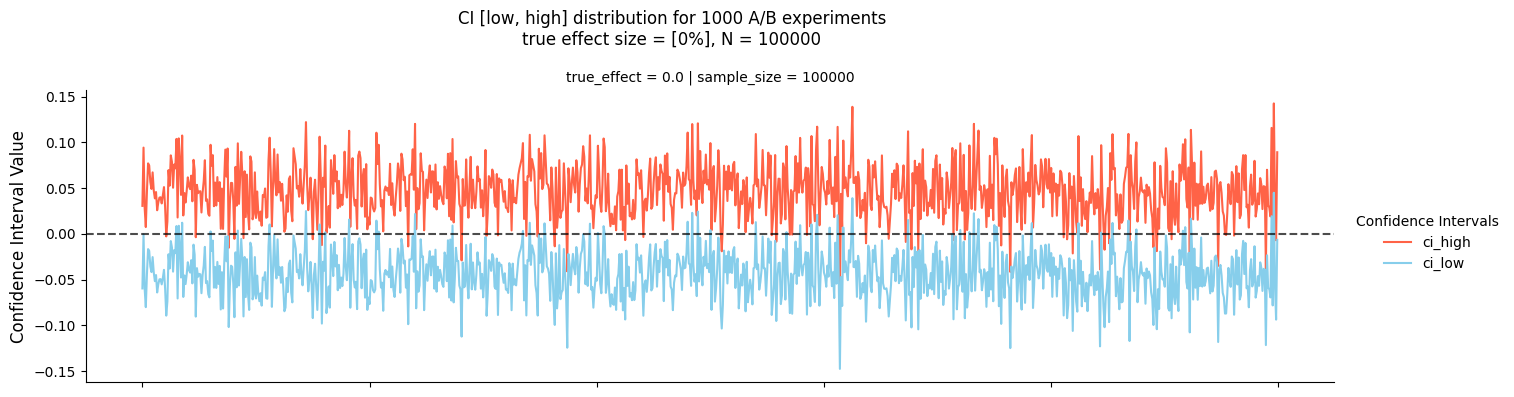

In [22]:
stats['index'] = [i for i in range(len(stats))]

stats_plot = stats.copy()

g = sns.FacetGrid(
    stats_plot,
    col = 'sample_size', row = 'true_effect',
    height=4, aspect=3, sharex=True, 
)

g.map_dataframe(
    sns.lineplot,
    x='index',
    y='ci_h',
    color='tomato',
    label='ci_high'
)

g.map_dataframe(
    sns.lineplot,
    x='index',
    y='ci_l',
    color='skyblue',
    label='ci_low'
)

g.refline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
# g.refline(y=0.05, color='green', linestyle=':', linewidth=1.5, alpha=0.5)


for ax in g.axes.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('CI')
    ax.set_xticklabels([])
    
# Add axis labels
g.set_axis_labels('', 'Confidence Interval Value', fontsize=12)

# Add legend
g.add_legend(title='Confidence Intervals', fontsize=10)
sns.move_legend(g, "upper right", bbox_to_anchor=(1.12, 0.5), frameon=False)
    
g.fig.suptitle(f"CI [low, high] distribution for {RANGE} A/B experiments\ntrue effect size = [{stats_plot.true_effect.unique()[0]:.0%}], N = {stats_plot.sample_size.unique()[0]}")
g.fig.tight_layout()
